In [5]:
# Esame 654AA - a.a. 2025/2026
# Studenti: Leonardo Celati, Samuele Taviano
# Matricole: 660185,

In [6]:
import importlib

from sympy import false

import cross_common as cr
import cup_common as cc
import knn_common as kc
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsRegressor


In [7]:
importlib.reload(cc)
importlib.reload(kc)
importlib.reload(cr)

<module 'cross_common' from '/Users/leonardo/workspace/library/source/it.unipi.654AA/notebooks/cross_common.py'>

In [8]:
# The common fold strategy used trough all models
common_cv = cr.common_fold_strategy(False)
default_krange = list(range(1, 41, 2)) # <-- it means [1, 3, 5,..., 41]
common_scoring = cr.common_scoring()
scaler = StandardScaler()

default_pipe = Pipeline([
    ("scaler", scaler),
    ("model", KNeighborsRegressor())
])

default_param_grid = {
    "model__n_neighbors": default_krange,
    "model__weights": ["uniform", "distance"],
    "model__p": [1, 2],          # 1=Manhattan, 2=Euclidean
    "model__metric": ["minkowski"]
}

<h2>Cup Dataset</h2>
<hr/>

<h4>Data Loading</h4>
<p>Load and introspect data from monk training and test set.</p>

In [9]:
df_train, df_test = cc.load_set()

# The train set used for model selection
X_tr, y_tr = cc.prepare_dataset(df_train)
X_ts, y_ts = cc.prepare_dataset(df_test)

features_names = X_tr.columns
cr.dataset_introspection(df_train, df_test)

,Property,Training,Test
0,Number of samples,500,1000
1,Number of features,15,11
2,Class values,[],[]
3,Class balance,[],[]


<h4>Model selection</h4>

In [10]:
importlib.reload(cr)
model_baseline = cr.model_baseline(X_tr, y_tr,common_cv)

----------------------------------------
Baseline: DummyRegressor()
Mean baseline: 35.79302825927734
Scorer: make_scorer(neg_mean_eclidean_error, greater_is_better=False, response_method='predict')
Raw scores: [-36.10307312 -34.5480423  -35.62013626 -35.9157486  -36.77814102]


In [11]:
importlib.reload(cc)
gs = GridSearchCV(
    default_pipe,
    param_grid=default_param_grid,
    scoring=common_scoring,
    cv=common_cv,
    n_jobs=-1,
    return_train_score=True
)

gs.fit(X_tr, y_tr)
best_estimator = gs.best_estimator_
best_model, best_params = cr.extract_best_pipeline_metrics_from_grid(gs)
cr.grid_introspection(gs)

Total model explored: 80
Best params: {'regressor__metric': 'minkowski', 'regressor__n_neighbors': 3, 'regressor__p': 2, 'regressor__weights': 'distance'}
Best score: -6.938927922669909
Best model: Pipeline(steps=[('scaler', StandardScaler()),
                ('regressor',
                 KNeighborsRegressor(n_neighbors=3, weights='distance'))])


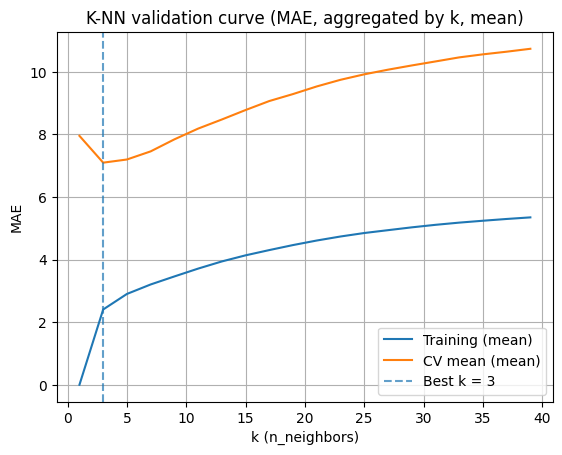

In [12]:
importlib.reload(kc)
kc.plot_knn_validation_curve_from_gs(gs,"mean")

<p>With distance-weighted KNN, the training error might be zero by construction, as each training point dominates its own prediction. Therefore, only the validation curve provides meaningful information about generalization.</p>

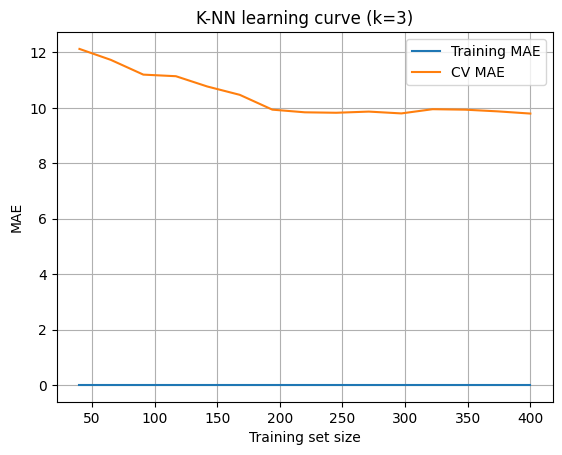

In [13]:
importlib.reload(cc)
kc.plot_knn_learning_curve(best_model, X_tr, y_tr, common_cv, scoring=common_scoring)

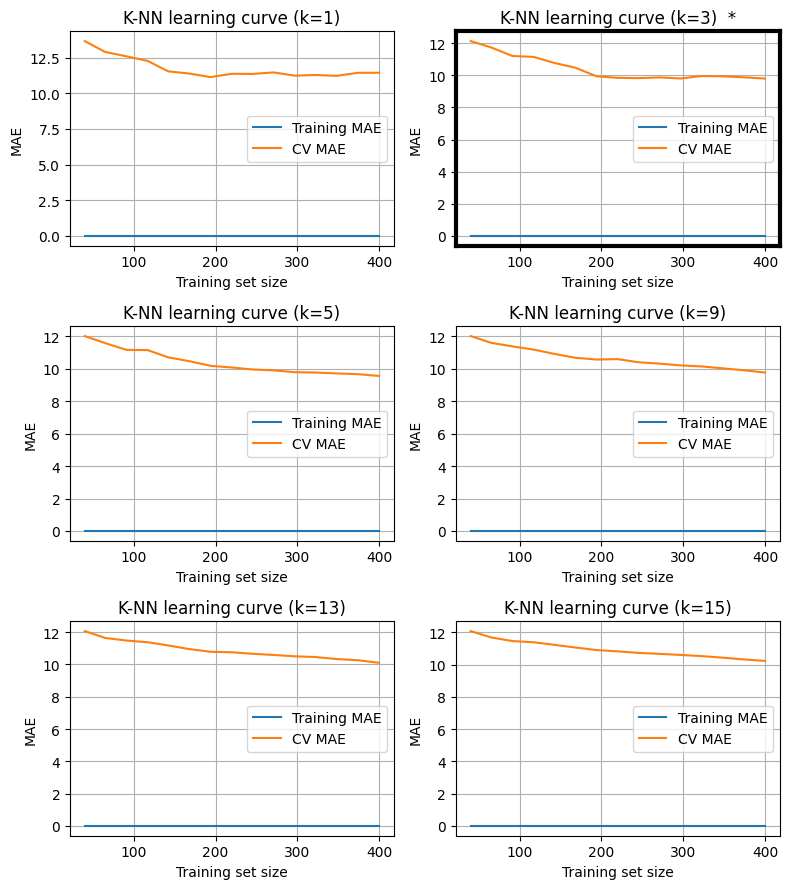

In [14]:
importlib.reload(kc)
kc.plot_knn_learning_curves_grid(
    best_model,
    X=X_tr,
    y=y_tr,
    cv=common_cv,
    score_correction=-1,
    scoring=common_scoring
)

<h4>KFold</h4>

In [15]:
importlib.reload(kc)
importlib.reload(cc)

runner = cr.SklearnRegressorRunner(best_estimator)
kf_result = cr.kfold(runner, X_tr, y_tr, common_cv)

  
Perform fold: 0, train size: 400, val size: 100
Fold summary
--------------------------------------------------------------------------------
Validation MSE  | 83.5264
Validation RMSE | 9.1393
Validation MEE  | 14.8727
Validation MAE  | 6.6341
Train           | samples: 400
Validation      | samples: 100
  
Perform fold: 1, train size: 400, val size: 100
Fold summary
--------------------------------------------------------------------------------
Validation MSE  | 93.3826
Validation RMSE | 9.6635
Validation MEE  | 16.0250
Validation MAE  | 7.1061
Train           | samples: 400
Validation      | samples: 100
  
Perform fold: 2, train size: 400, val size: 100
Fold summary
--------------------------------------------------------------------------------
Validation MSE  | 95.3689
Validation RMSE | 9.7657
Validation MEE  | 15.3649
Validation MAE  | 6.8449
Train           | samples: 400
Validation      | samples: 100
  
Perform fold: 3, train size: 400, val size: 100
Fold summary
---------

In [16]:
importlib.reload(cc)
cr.kfold_regression_table(kf_result, use="mae", derive_rmse=True)

,TR_MAE,VL_MAE,Gap(TR-VL),TR_RMSE,VL_RMSE
Fold,,,,,
1,0.0,6.634068,6.634068,0.0,2.575668
2,0.0,7.106069,7.106069,0.0,2.665721
3,0.0,6.844892,6.844892,0.0,2.616274
4,0.0,7.312322,7.312322,0.0,2.704131
5,0.0,6.797289,6.797289,0.0,2.607161
MEAN,0.0,6.938928,6.938928,0.0,2.633791
STD,0.0,0.268888,0.268888,0.0,0.050895


In [17]:
importlib.reload(cc)
mean, std = cr.extract_mean_std(kf_result, "fold_vl_mse")
print(f"{mean:.4f} ± {std:.4f}")

91.7748 ± 7.3024


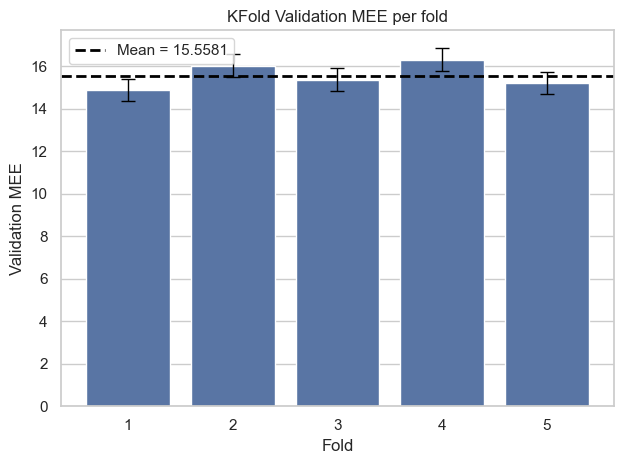

In [18]:
cr.plot_kfold_mee(kf_result)

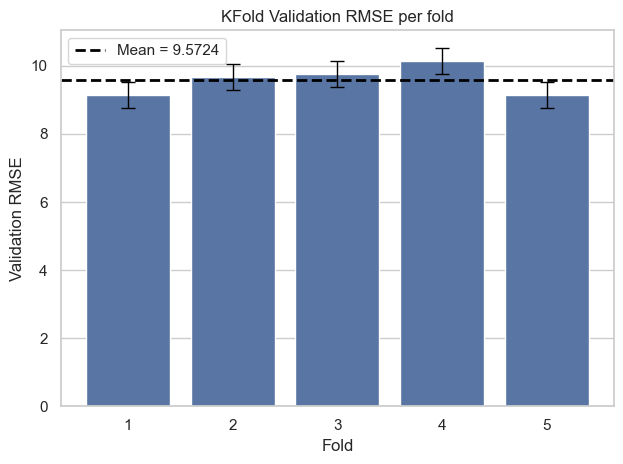

In [19]:
cr.plot_kfold_rmse(kf_result)

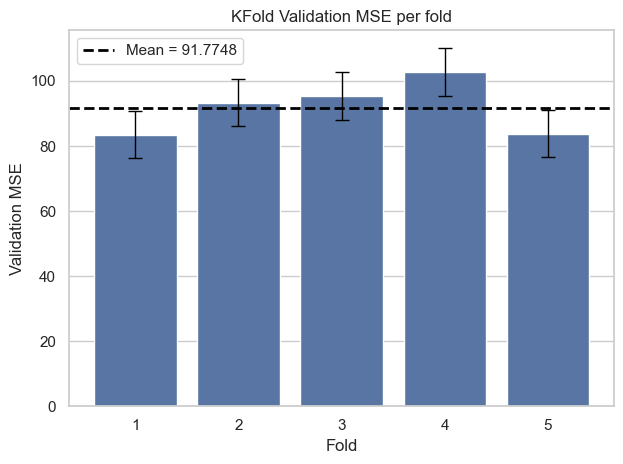

In [20]:
cr.plot_kfold_mse(kf_result)

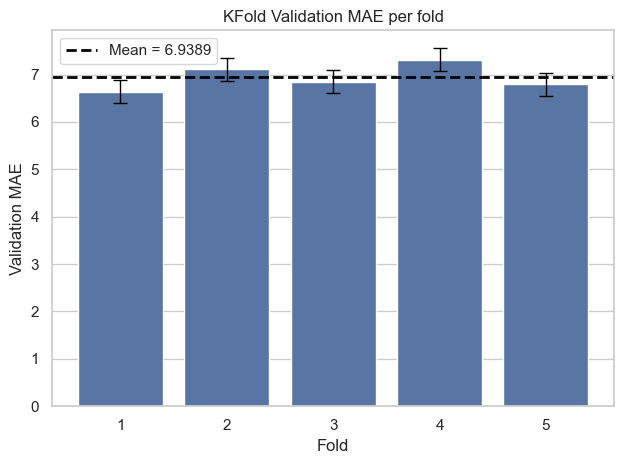

In [21]:
cr.plot_kfold_mae(kf_result)

In [22]:
cr.kfold_regression_table(kf_result, use="mee", derive_rmse=True)

,TR_MEE,VL_MEE,Gap(TR-VL),TR_RMSE,VL_RMSE
Fold,,,,,
1,0.0,14.872653,14.872653,0.0,3.856508
2,0.0,16.025041,16.025041,0.0,4.003129
3,0.0,15.364915,15.364915,0.0,3.919811
4,0.0,16.311005,16.311005,0.0,4.038688
5,0.0,15.216827,15.216827,0.0,3.900875
MEAN,0.0,15.558088,15.558088,0.0,3.943802
STD,0.0,0.593407,0.593407,0.0,0.075103


<h4>Test predictions</h4>
<p>Test predictions on the test set.</p>

In [23]:
y_pred = best_estimator.predict(X_ts)
print(y_pred)

[[ -2.79324896  -2.14789798   7.44322897  -4.99472277]
 [-14.89588736  -3.69486546 -47.97000607   7.45547685]
 [ -2.59380732  -3.71783239  -3.5057078    7.29190959]
 ...
 [ -9.51488283  12.8594663   26.00300477  -3.50416596]
 [ 18.36657819   9.35232599 -19.5671548   26.86842462]
 [ -4.49523958   1.44233058   9.05479381  -0.69219692]]
